In [1]:
import os
import glob
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torch.optim.lr_scheduler import OneCycleLR
import time
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score


/home/vimarsh/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:

class NpyImageDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        """
        Args:
            data_dir (string): Directory with all the .npy image files.
            transform (callable, optional): Optional transform to be applied on a sample.
        """
        self.data_dir = data_dir
        self.transform = transform
        
        # Collect all .npy files and their labels based on folder names.
        self.image_paths = []
        self.labels = []
        class_dirs = [d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))]
        print("Found classes:", class_dirs)
        self.class_to_idx = {class_name: i for i, class_name in enumerate(class_dirs)}
        for class_name in class_dirs:
            class_path = os.path.join(data_dir, class_name)
            class_idx = self.class_to_idx[class_name]
            for file_path in glob.glob(os.path.join(class_path, '*.npy')):
                self.image_paths.append(file_path)
                self.labels.append(class_idx)
    
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        image = np.load(self.image_paths[idx])
        label = self.labels[idx]
        image = torch.from_numpy(image).float()  # Expecting shape (1, H, W)
        if self.transform:
            image = self.transform(image)
        return image, label

In [3]:
# Adjust these paths as needed
# train_dir = "/kaggle/input/deeplense-lensing-classes/dataset/train"
# val_dir = "/kaggle/input/deeplense-lensing-classes/dataset/val"

train_dir = "/home/vimarsh/Desktop/3-2/GSoC/ML4Sci/dataset/dataset/train"
val_dir = "/home/vimarsh/Desktop/3-2/GSoC/ML4Sci/dataset/dataset/val"

# Simple transformation: here we assume the .npy images are already normalized
transform = transforms.Compose([
    # Uncomment if you wish to apply additional transforms
    # transforms.Resize((150,150)),
    transforms.Normalize((0.5,), (0.5,)),
    transforms.RandomRotation(10),  # Small random rotations
    transforms.RandomHorizontalFlip(),  # Random horizontal flips
    transforms.RandomVerticalFlip(),  # Random vertical flips
    # adding a small amount of noise for robustness
    transforms.Lambda(lambda x: x + 0.02 * torch.randn_like(x)),
    
])

# Create datasets and dataloaders
train_dataset = NpyImageDataset(train_dir, transform=transform)
val_dataset = NpyImageDataset(val_dir, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=True, num_workers=4)


Found classes: ['no', 'vort', 'sphere']
Found classes: ['no', 'vort', 'sphere']


In [4]:
def deltamat(shape):
    kk = np.zeros((shape, shape))
    for i in range(shape):
        for j in range(shape):
            kk[i][j] = np.sqrt((i+1)**2 + (j+1)**2)
    return torch.tensor(kk, dtype=torch.float32)

# Create a positional matrix for images of size 150x150
pos_matrix = deltamat(150).unsqueeze(0).to("cuda")



In [5]:
from torchvision.models import resnet18, resnet34
from itertools import cycle
from sklearn.metrics import auc
class LensPINN(nn.Module):
    def __init__(self, pos_mat):
        super(LensPINN, self).__init__()
        self.pos_mat = pos_mat  # (1,150,150)
        
        # Encoder: feature extractor from a grayscale image using a resnet18 backbone.
        # self.encoder = timm.create_model("resnet18", pretrained=True, drop_rate=0.1)
        self.encoder = resnet18(pretrained=False)
        # Adjust first convolution to accept 1 channel
        self.encoder.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        # Change final FC to output an image-sized vector (150x150)
        self.encoder.fc = nn.Sequential(
            # nn.Dropout(0.05),
            nn.Linear(512, 150*150, bias=True)
        )
        
        # Physics Branch: predicts 3 parameters (theta_E, gamma, phi)
        # self.physics_branch = timm.create_model("resnet18", pretrained=True, drop_rate=0.1)
        self.physics_branch = resnet18(pretrained=False)
        # Modify input to 2 channels (concatenated original and physics-informed image)
        self.physics_branch.conv1 = nn.Conv2d(2, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.physics_branch.fc = nn.Sequential(
            # nn.Dropout(0.05),
            nn.Linear(512, 3, bias=True)
        )
    def generate_coord_grid(self, H, W, device):
        xs = torch.linspace(-1, 1, W, device=device)
        ys = torch.linspace(-1, 1, H, device=device)
        grid_y, grid_x = torch.meshgrid(ys, xs, indexing='ij')
        grid = torch.stack([grid_x, grid_y], dim=0)  # shape: (2,H,W)
        return grid.unsqueeze(0)  # shape: (1,2,H,W)
    
    def lensing_equation(self, coord, theta_E, gamma, phi):
        """
        Complex gravitational lensing equation:
            beta = theta - theta_E*(theta/|theta|) - gamma * A(phi)*theta,
        where A(phi) = [[cos(2phi), sin(2phi)], [sin(2phi), -cos(2phi)]]
        coord: (batch,2,H,W)
        theta_E, gamma, phi: each of shape (batch,)
        """
        eps = 1e-6
        batch = coord.size(0)
        theta_E = theta_E.view(batch, 1, 1, 1)
        gamma   = gamma.view(batch, 1, 1, 1)
        phi     = phi.view(batch, 1, 1, 1)
        # Compute unit vector in direction of theta (pixel coordinate)
        norm = torch.sqrt(coord[:,0:1,:,:]**2 + coord[:,1:2,:,:]**2 + eps)
        unit_coord = coord / norm
        
        # SIS deflection
        defl_SIS = theta_E * unit_coord
        
        # External shear deflection via shear matrix A(phi)
        cos2phi = torch.cos(2*phi)
        sin2phi = torch.sin(2*phi)
        theta_x = coord[:,0:1,:,:]
        theta_y = coord[:,1:2,:,:]
        shear_x = cos2phi * theta_x + sin2phi * theta_y
        shear_y = sin2phi * theta_x - cos2phi * theta_y
        defl_shear = gamma * torch.cat([shear_x, shear_y], dim=1)
        
        beta_pred = coord - defl_SIS - defl_shear
        return beta_pred
    
    def forward(self, x):
        # x: (batch,1,150,150)
        batch = x.size(0)
        # Use encoder to obtain an angular distortion map
        enc_out = self.encoder(x)              # shape: (batch,150*150)
        enc_out = enc_out.view(batch, 1, 150, 150)  # reshape to (batch,1,150,150)
        ang_dist = enc_out * self.pos_mat      # element-wise multiplication
        
        # Compute a preliminary source image using a simple subtraction
        src_img = x - ang_dist                 # shape: (batch,1,150,150)
        # Concatenate the original and source images to form 2-channel input
        two_chan = torch.cat([x, src_img], dim=1)  # shape: (batch,2,150,150)
        
        # Get physics parameters: they serve as classification logits as well.
        params = self.physics_branch(two_chan)  # shape: (batch,3)
        # For physics equation, we interpret params as [theta_E, gamma, phi]
        theta_E = params[:,0]
        gamma   = params[:,1]
        phi     = params[:,2]
        
        # Generate a coordinate grid (normalized between -1 and 1)
        coord_grid = self.generate_coord_grid(150, 150, x.device)  # (1,2,150,150)
        coord_grid = coord_grid.repeat(batch, 1, 1, 1)  # (batch,2,150,150)
        
        # Compute the predicted source position using the complex lensing equation
        beta_pred = self.lensing_equation(coord_grid, theta_E, gamma, phi)
        
        # Return both the predicted parameters (used for classification) and beta_pred for physics loss.
        return params, beta_pred

In [6]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total_cls_loss = 0.0
    total_phys_loss = 0.0
    total_samples = 0
    physics_loss_fn = nn.MSELoss()
    for imgs, labels in tqdm(loader, desc="Training", leave=False):
        imgs = imgs.to(device)          # shape: (batch,1,150,150)
        labels = labels.to(device)
        optimizer.zero_grad()
        # Forward pass returns classification logits (params) and physics prediction beta_pred.
        params, beta_pred = model(imgs)
        # Classification loss: use cross entropy on params (3 classes)
        loss_cls = criterion(F.log_softmax(params, dim=1), labels)
        # Physics loss: assume target source position is centered (all zeros)
        beta_target = torch.zeros_like(beta_pred).to(device)
        loss_phys = physics_loss_fn(beta_pred, beta_target)
        # physics_weight = min(0.2, 0.2 * (1.0 / (1.0 + loss_phys.item())))
        # loss = loss_cls + physics_weight * loss_phys
        loss = loss_cls + 0.2 * loss_phys
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        total_cls_loss += loss_cls.item() * imgs.size(0)
        total_phys_loss += loss_phys.item() * imgs.size(0)
        total_samples += imgs.size(0)
    
    avg_loss = total_loss / total_samples
    avg_cls_loss = total_cls_loss / total_samples
    avg_phys_loss = total_phys_loss / total_samples
    
    return avg_loss, avg_cls_loss, avg_phys_loss

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_cls_loss = 0.0
    total_phys_loss = 0.0
    total_samples = 0
    correct = 0
    y_true = []
    y_scores = []
    physics_loss_fn = nn.MSELoss()
    
    with torch.no_grad():
        for imgs, labels in tqdm(loader, desc="Evaluating", leave=False):
            imgs = imgs.to(device)
            labels = labels.to(device)
            params, beta_pred = model(imgs)
            
            # Calculate losses
            loss_cls = criterion(F.log_softmax(params, dim=1), labels)
            beta_target = torch.zeros_like(beta_pred).to(device)
            loss_phys = physics_loss_fn(beta_pred, beta_target)
            loss = loss_cls + 0.2 * loss_phys
            
            total_loss += loss.item() * imgs.size(0)
            total_cls_loss += loss_cls.item() * imgs.size(0)
            total_phys_loss += loss_phys.item() * imgs.size(0)
            total_samples += imgs.size(0)
            
            preds = torch.argmax(F.log_softmax(params, dim=1), dim=1)
            correct += (preds == labels).sum().item()
            y_true.extend(labels.cpu().numpy())
            y_scores.extend(F.softmax(params, dim=1).cpu().numpy())
    
    acc = correct / total_samples
    avg_loss = total_loss / total_samples
    avg_cls_loss = total_cls_loss / total_samples
    avg_phys_loss = total_phys_loss / total_samples
    
    print(f"Val Loss: {avg_loss:.4f}, Val Cls Loss: {avg_cls_loss:.4f}, Val Phys Loss: {avg_phys_loss:.4f}, Accuracy: {acc:.4f}")
    
    # ROC AUC for each class
    y_true = np.array(y_true)
    y_scores = np.array(y_scores)
    num_classes = y_scores.shape[1]
    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    # For all classes
    for i in range(num_classes):
        y_true_class = (y_true == i).astype(int)
        y_score_class = y_scores[:, i]
        fpr[i], tpr[i], _ = roc_curve(y_true_class, y_score_class)
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Micro-average calculation
    y_true_flat = np.eye(num_classes)[y_true].ravel()
    y_score_flat = y_scores.ravel()
    fpr["micro"], tpr["micro"], _ = roc_curve(y_true_flat, y_score_flat)
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

    # Plotting ROC curves
    plt.figure(figsize=(10, 8))
    plt.plot(fpr["micro"], tpr["micro"],
             label=f'Micro-average ROC (AUC = {roc_auc["micro"]:.2f})',
             color='deeppink', linestyle='-', linewidth=2)

    colors = cycle(['aqua', 'darkorange', 'cornflowerblue'])
    class_names = ['No Substructure', 'Subhalo', 'Vortex']

    for i, color, class_name in zip(range(num_classes), colors, class_names):
        plt.plot(fpr[i], tpr[i], color=color, linestyle='-', linewidth=2,
                 label=f'ROC for {class_name} (AUC = {roc_auc[i]:.2f})')

    plt.plot([0, 1], [0, 1], 'k--', linewidth=2)
    plt.xlim([-0.01, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()
    
    return avg_loss, avg_cls_loss, avg_phys_loss

def plot_losses(train_losses, train_cls_losses, train_phys_losses, 
                val_losses, val_cls_losses, val_phys_losses):
    """
    Plot training and validation losses with their components.
    
    Args:
        train_losses: List of total training losses
        train_cls_losses: List of classification training losses
        train_phys_losses: List of physics training losses
        val_losses: List of total validation losses
        val_cls_losses: List of classification validation losses
        val_phys_losses: List of physics validation losses
    """
    epochs = range(1, len(train_losses) + 1)
    
    fig, axs = plt.subplots(3, 1, figsize=(12, 15))
    
    # Total loss
    axs[0].plot(epochs, train_losses, 'bo-', label='Training Loss')
    axs[0].plot(epochs, val_losses, 'ro-', label='Validation Loss')
    axs[0].set_title('Total Loss over Epochs')
    axs[0].set_xlabel('Epochs')
    axs[0].set_ylabel('Loss')
    axs[0].legend()
    axs[0].grid(True)
    
    # Classification loss
    axs[1].plot(epochs, train_cls_losses, 'bo-', label='Training Classification Loss')
    axs[1].plot(epochs, val_cls_losses, 'ro-', label='Validation Classification Loss')
    axs[1].set_title('Classification Loss over Epochs')
    axs[1].set_xlabel('Epochs')
    axs[1].set_ylabel('Loss')
    axs[1].legend()
    axs[1].grid(True)
    
    # Physics loss
    axs[2].plot(epochs, train_phys_losses, 'bo-', label='Training Physics Loss')
    axs[2].plot(epochs, val_phys_losses, 'ro-', label='Validation Physics Loss')
    axs[2].set_title('Physics Loss over Epochs')
    axs[2].set_xlabel('Epochs')
    axs[2].set_ylabel('Loss')
    axs[2].legend()
    axs[2].grid(True)
    
    plt.tight_layout()
    plt.show()

/home/vimarsh/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/vimarsh/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Epoch 1/10


Val Loss: 1.1550, Val Cls Loss: 1.1434, Val Phys Loss: 0.0578, Accuracy: 0.3323


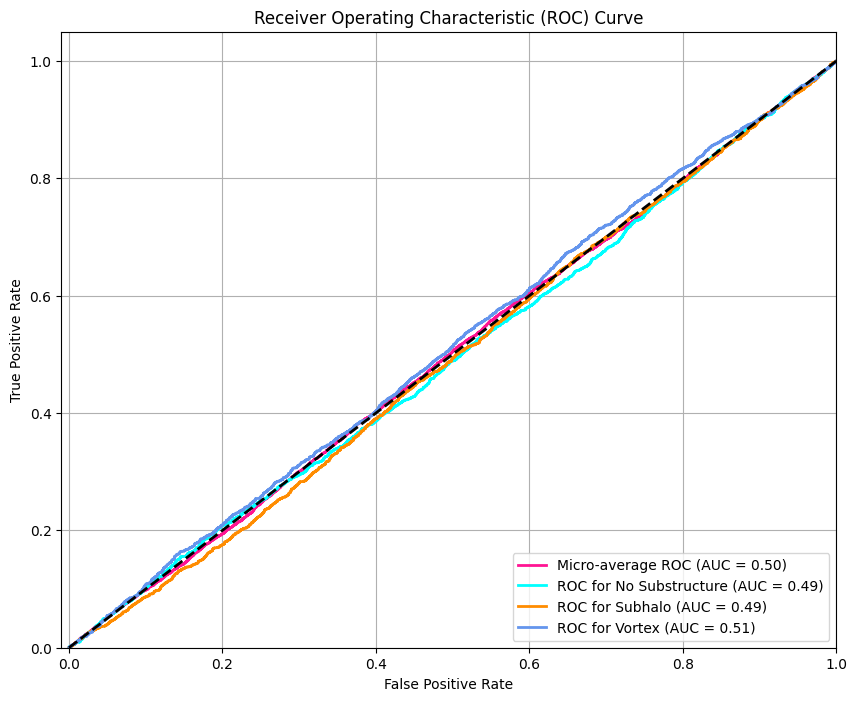

/home/vimarsh/.local/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:243: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


Train Loss: 1.141232 | Val Loss: 1.154970 | LR: 0.000401
Best model saved!
------------------------------------------------------------
Epoch 2/10


Val Loss: 1.1411, Val Cls Loss: 1.1302, Val Phys Loss: 0.0540, Accuracy: 0.3333


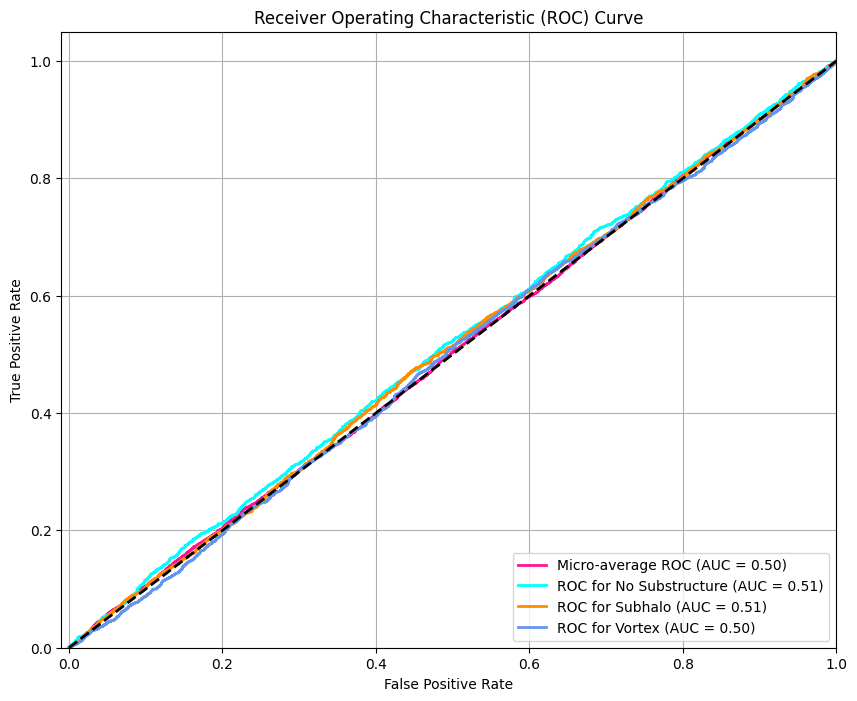

/home/vimarsh/.local/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:243: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


Train Loss: 1.133648 | Val Loss: 1.141052 | LR: 0.000401
Best model saved!
------------------------------------------------------------
Epoch 3/10


Val Loss: 1.1245, Val Cls Loss: 1.1086, Val Phys Loss: 0.0793, Accuracy: 0.3333


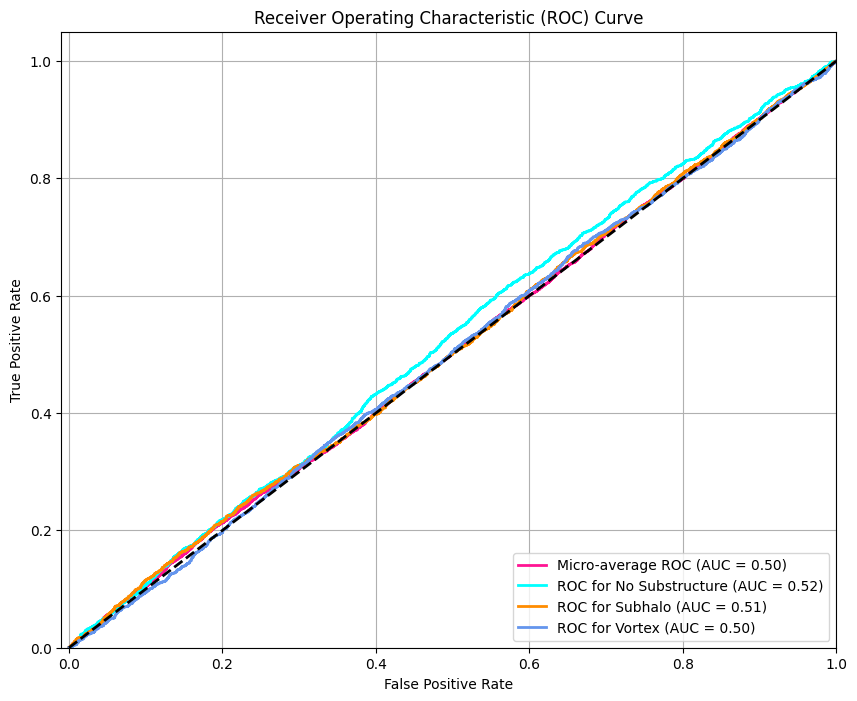

/home/vimarsh/.local/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:243: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


Train Loss: 1.130369 | Val Loss: 1.124487 | LR: 0.000401
Best model saved!
------------------------------------------------------------
Epoch 4/10


Val Loss: 1.1276, Val Cls Loss: 1.1127, Val Phys Loss: 0.0746, Accuracy: 0.3303


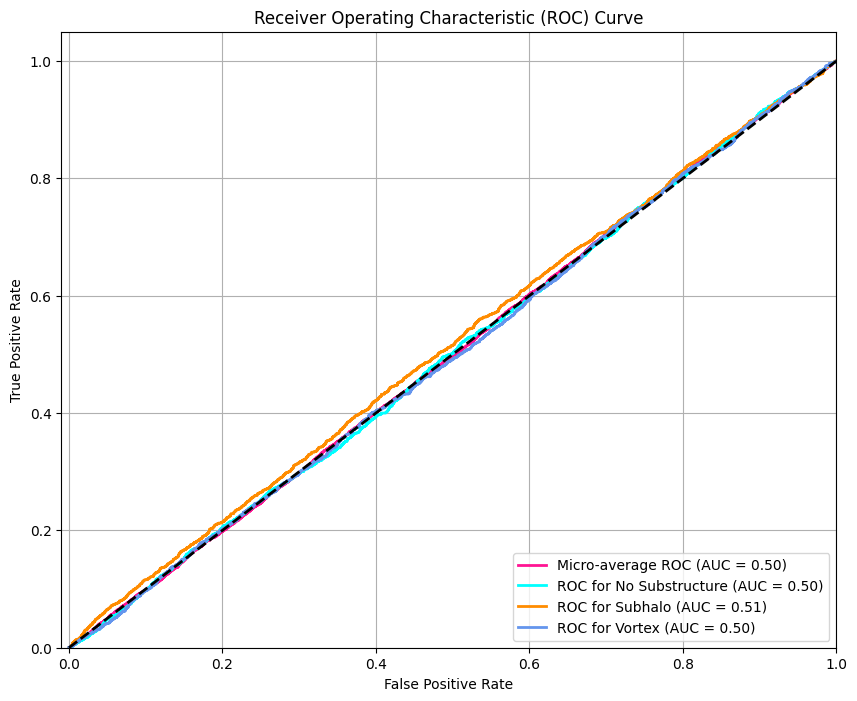

/home/vimarsh/.local/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:243: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


Train Loss: 1.127709 | Val Loss: 1.127599 | LR: 0.000401
------------------------------------------------------------
Epoch 5/10


Val Loss: 1.1258, Val Cls Loss: 1.1110, Val Phys Loss: 0.0740, Accuracy: 0.3333


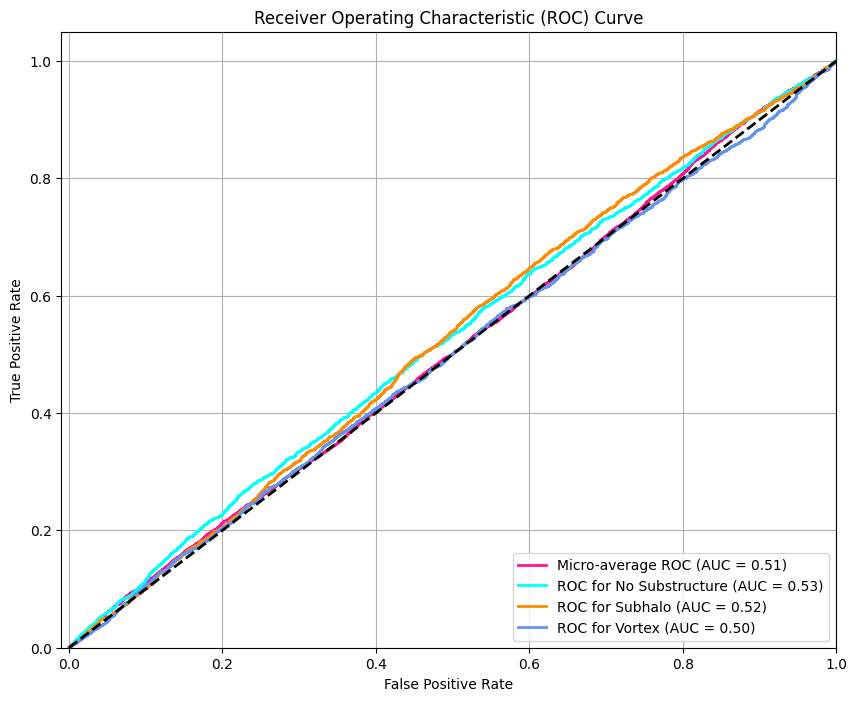

/home/vimarsh/.local/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:243: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


Train Loss: 1.126885 | Val Loss: 1.125842 | LR: 0.000401
------------------------------------------------------------
Epoch 6/10


Val Loss: 1.1228, Val Cls Loss: 1.1021, Val Phys Loss: 0.1036, Accuracy: 0.3345


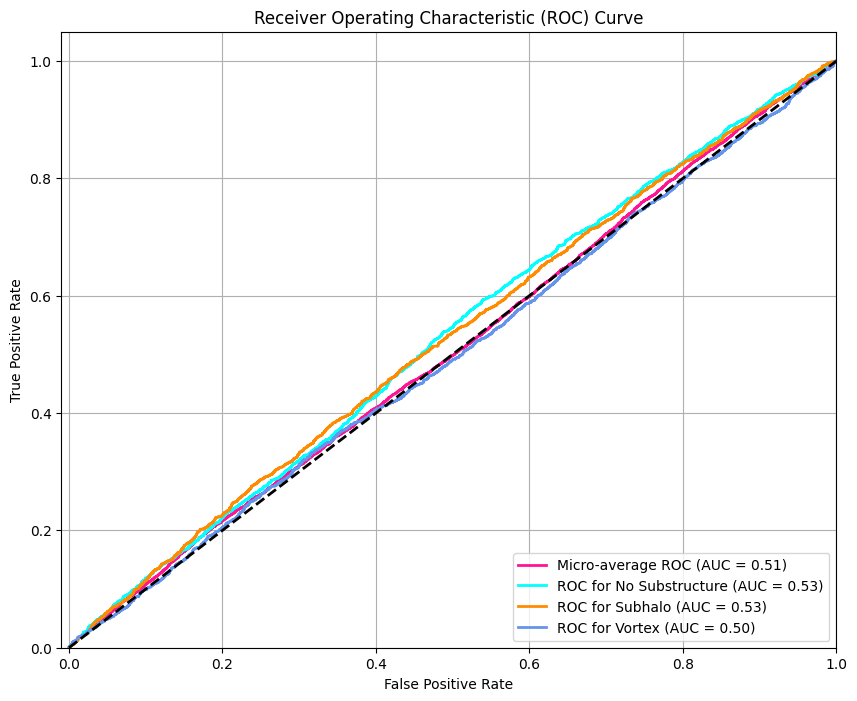

/home/vimarsh/.local/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:243: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


Train Loss: 1.127369 | Val Loss: 1.122821 | LR: 0.000401
Best model saved!
------------------------------------------------------------
Epoch 7/10


Val Loss: 1.1253, Val Cls Loss: 1.1010, Val Phys Loss: 0.1214, Accuracy: 0.3412


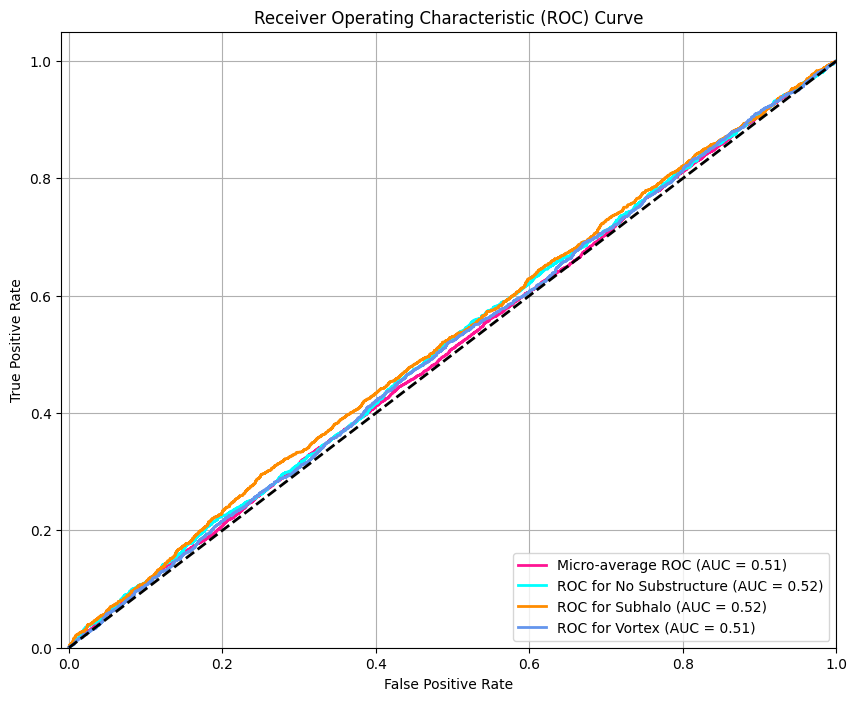

/home/vimarsh/.local/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:243: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


Train Loss: 1.127202 | Val Loss: 1.125331 | LR: 0.000401
------------------------------------------------------------
Epoch 8/10


Val Loss: 1.1323, Val Cls Loss: 1.0979, Val Phys Loss: 0.1724, Accuracy: 0.3364


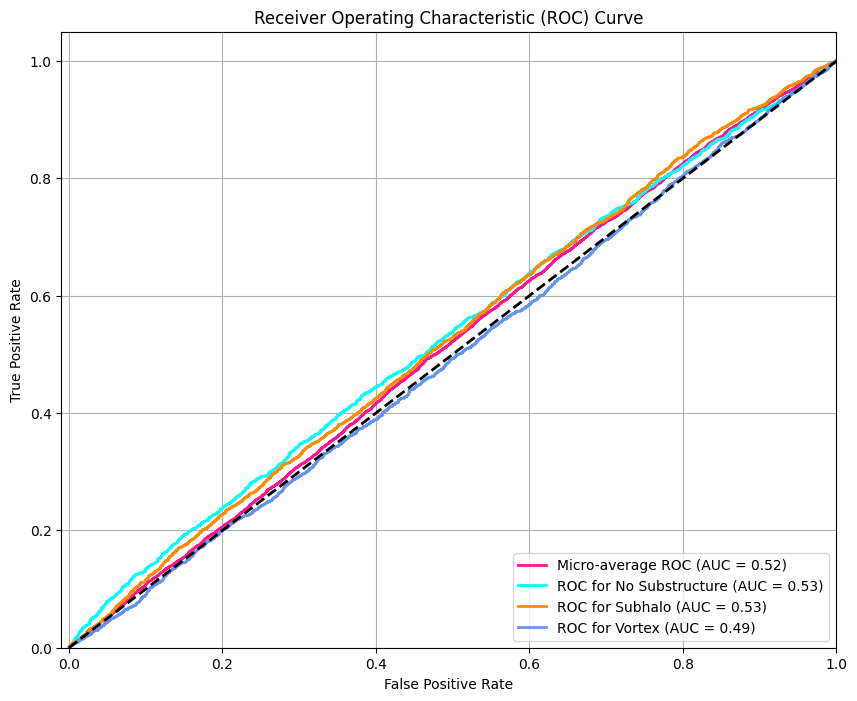

/home/vimarsh/.local/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:243: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


Train Loss: 1.127442 | Val Loss: 1.132346 | LR: 0.000401
------------------------------------------------------------
Epoch 9/10


Val Loss: 1.1280, Val Cls Loss: 1.0990, Val Phys Loss: 0.1449, Accuracy: 0.3333


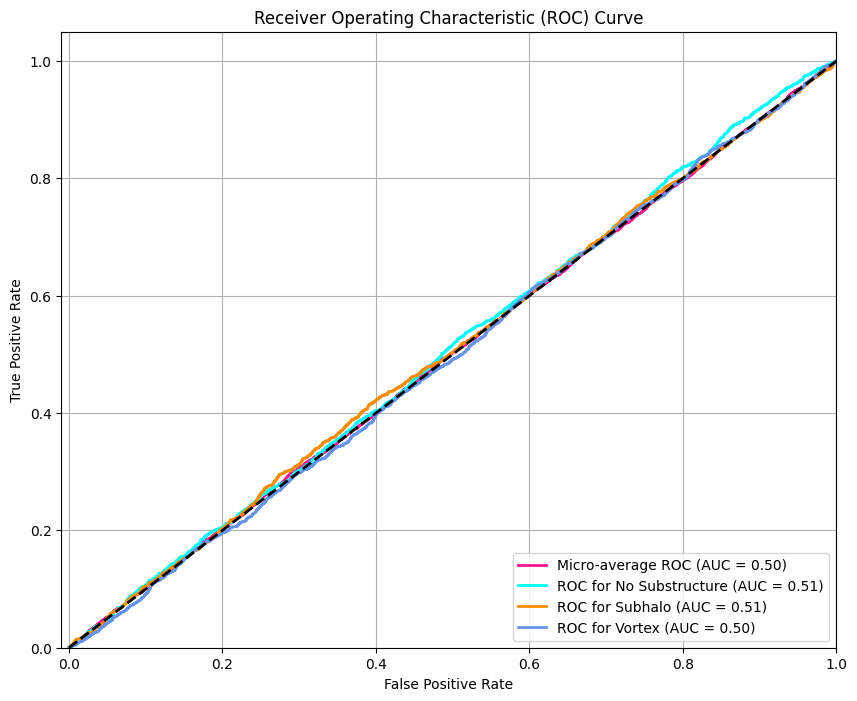

Train Loss: 1.125941 | Val Loss: 1.127997 | LR: 0.000401
Early stopping! after 9 epochs


/home/vimarsh/.local/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:243: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


In [7]:
import pdb

num_epochs = 10

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = LensPINN(pos_matrix).to(device)
optimizer = torch.optim.RAdam(model.parameters(), lr=0.001, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()
steps_per_epoch = len(train_loader)
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, min_lr=1e-6, verbose=True)

#some other optimizer and schedular
# optimizer = torch.optim.Adam(model.parameters(), lr=0.0005, weight_decay=1e-5)
# scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    # optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-6
# )
scheduler = OneCycleLR(optimizer, max_lr=0.01, epochs=num_epochs, steps_per_epoch=steps_per_epoch, pct_start=0.1, anneal_strategy="cos", final_div_factor=10)

train_losses = []
val_losses = []
best_val = np.inf
patience = 3
no_improve = 0


for epoch in range(num_epochs):
    print(f"Epoch {epoch+1}/{num_epochs}")
    train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
    val_loss = evaluate(model, val_loader, criterion, device)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    # pdb.set_trace()
    # print(val_loss[0]+val_loss[1])
    scheduler.step(val_loss[0])
    print(f"Train Loss: {train_loss[0]:.6f} | Val Loss: {val_loss[0]:.6f} | LR: {scheduler.get_last_lr()[0]:.6f}")
    
    if val_loss[0] < best_val:
        best_val = val_loss[0]
        no_improve = 0
        torch.save({
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'epoch': epoch,
            'val_loss': val_loss
        }, "./Bestmodel.model")
        print("Best model saved!")
    else:
        no_improve += 1
    if no_improve >= patience:
        print(f"Early stopping! after {epoch+1} epochs")
        break
    print("-"*60)


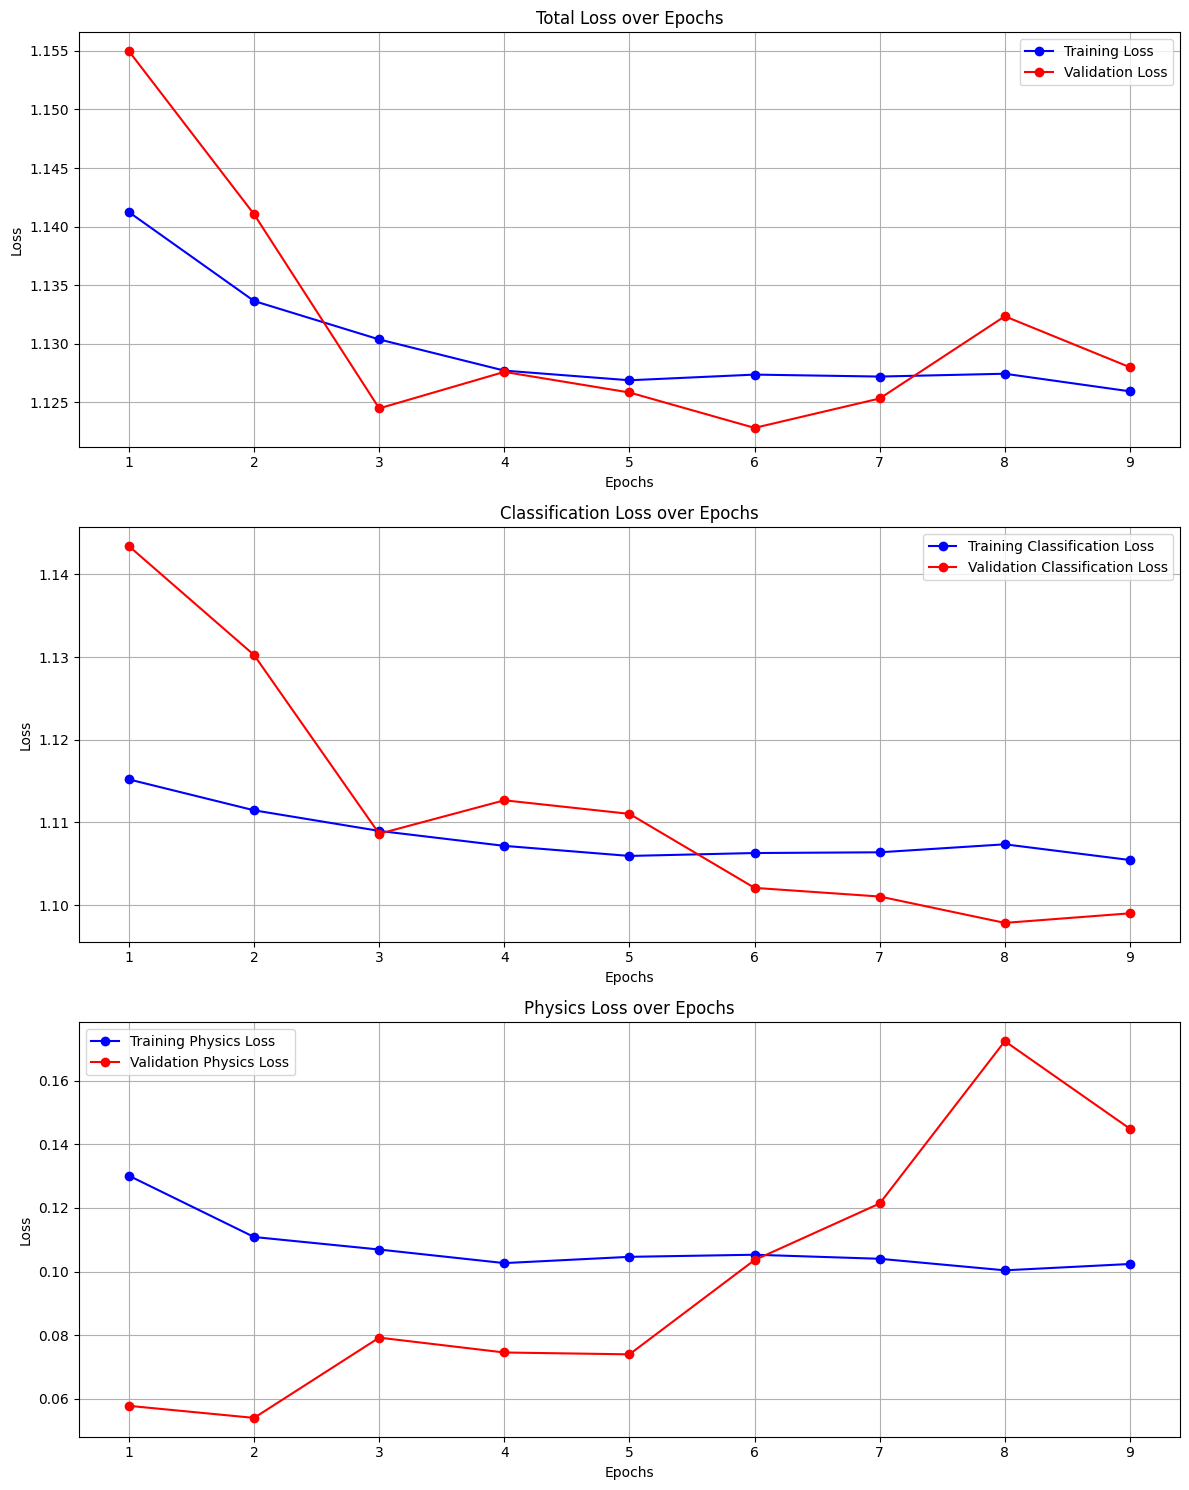

In [8]:
# Extract the different components from the loss tuples
train_total_losses = [x[0] for x in train_losses]
train_cls_losses = [x[1] for x in train_losses]
train_phys_losses = [x[2] for x in train_losses]

val_total_losses = [x[0] for x in val_losses]
val_cls_losses = [x[1] for x in val_losses]
val_phys_losses = [x[2] for x in val_losses]

# Use the detailed plotting function from cell 5
plot_losses(
    train_total_losses, 
    train_cls_losses, 
    train_phys_losses,
    val_total_losses, 
    val_cls_losses, 
    val_phys_losses
)